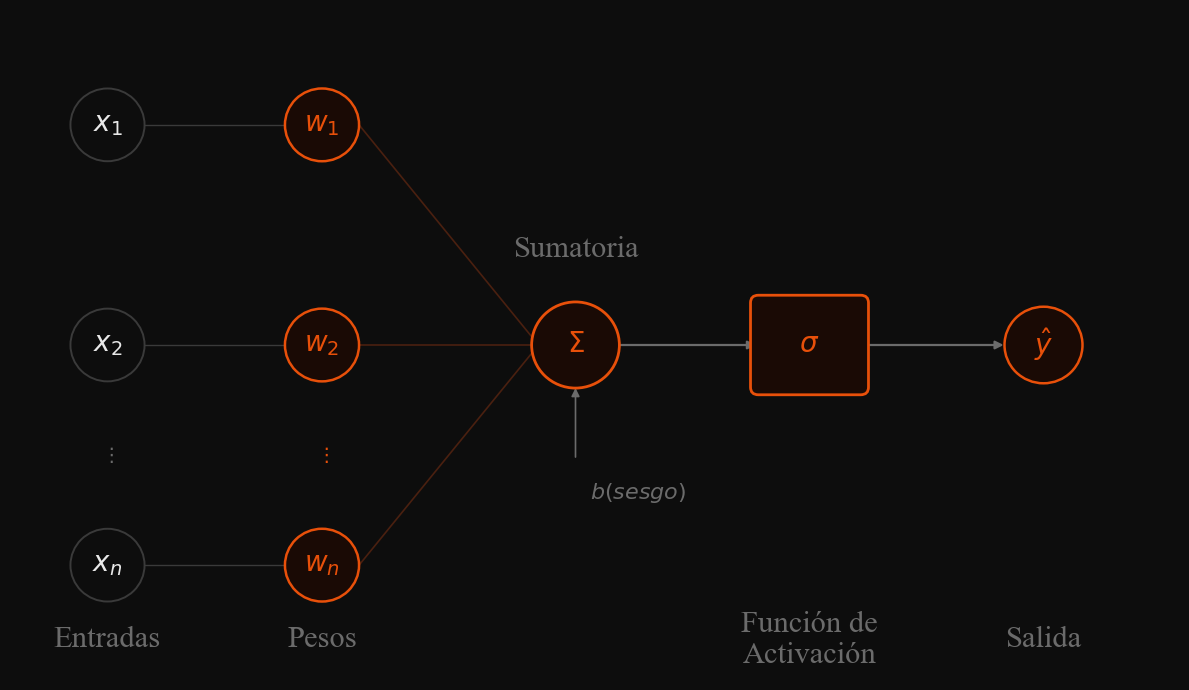

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib as mpl
import numpy as np

# ── Paleta CUNEF ──────────────────────────────────────────
CUNEF_ORANGE = "#E8500A"
CUNEF_AMBER  = "#F4A261"
CUNEF_DARK   = "#0D0D0D"
CUNEF_PANEL  = "#141414"
CUNEF_GRAY   = "#6B6B6B"
CUNEF_LGRAY  = "#3A3A3A"
WHITE        = "#E8E8E8"

mpl.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "figure.facecolor": CUNEF_DARK,
    "text.color":       WHITE,
})

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor(CUNEF_DARK)
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

# ── Helper: círculo ───────────────────────────────────────
def circulo(x, y, r=0.38, fc=CUNEF_DARK, ec=CUNEF_ORANGE, lw=1.8, zorder=4):
    c = plt.Circle((x, y), r, fc=fc, ec=ec, linewidth=lw, zorder=zorder)
    ax.add_patch(c)
    return c

# ── Helper: rectángulo redondeado ─────────────────────────
def rect_redondeado(x, y, w, h, fc=CUNEF_DARK, ec=CUNEF_ORANGE, lw=1.8, zorder=4):
    r = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.08",
        fc=fc, ec=ec, linewidth=lw, zorder=zorder
    )
    ax.add_patch(r)

# ── Helper: flecha ────────────────────────────────────────
def flecha(x1, y1, x2, y2, color=CUNEF_LGRAY, lw=1.2, style="-|>"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style,
                                color=color,
                                lw=lw,
                                mutation_scale=12),
                zorder=3)

# ── Helper: línea simple ──────────────────────────────────
def linea(x1, y1, x2, y2, color=CUNEF_LGRAY, lw=1.0, ls="-"):
    ax.plot([x1, x2], [y1, y2], color=color, lw=lw, ls=ls, zorder=2)

# ── Posiciones ────────────────────────────────────────────
# Columna entradas
xs_x = [(1.0, 5.8), (1.0, 3.5), (1.0, 1.2)]   # (x, y) de x1, x2, xn
# Columna pesos
xs_w = [(3.2, 5.8), (3.2, 3.5), (3.2, 1.2)]   # w1, w2, wn
# Sumatoria
sum_x, sum_y = 5.8, 3.5
# Activación
act_x, act_y = 8.2, 3.5
# Salida
sal_x, sal_y = 10.6, 3.5

# ── Líneas de conexión ────────────────────────────────────
# x → w
for (xx, xy), (wx, wy) in zip(xs_x, xs_w):
    linea(xx + 0.38, xy, wx - 0.38, wy, color=CUNEF_LGRAY, lw=1.0)

# w → Σ (converging lines, orange-ish)
for wx, wy in xs_w:
    linea(wx + 0.38, wy, sum_x - 0.38, sum_y,
          color="#4A2010", lw=1.2)

# Σ → σ
flecha(sum_x + 0.38, sum_y, act_x - 0.52, act_y,
       color=CUNEF_GRAY, lw=1.6)

# σ → ŷ
flecha(act_x + 0.52, act_y, sal_x - 0.38, sal_y,
       color=CUNEF_GRAY, lw=1.6)

# Bias ↑ → Σ (flecha desde abajo)
flecha(sum_x, 2.3, sum_x, sum_y - 0.42,
       color=CUNEF_GRAY, lw=1.2)

# ── Nodos: Entradas (x1, x2, xn) ─────────────────────────
labels_x = [r"$x_1$", r"$x_2$", r"$x_n$"]
for (xx, xy), lbl in zip(xs_x, labels_x):
    circulo(xx, xy, ec=CUNEF_LGRAY, fc=CUNEF_DARK, lw=1.4)
    ax.text(xx, xy, lbl, ha="center", va="center",
            fontsize=20, color=WHITE, zorder=5)

# Puntos suspensivos entre x2 y xn
ax.text(xs_x[0][0], (xs_x[1][1] + xs_x[2][1]) / 2,
        r"$\vdots$", ha="center", va="center",
        fontsize=14, color=CUNEF_GRAY, zorder=5)

# ── Nodos: Pesos (w1, w2, wn) ────────────────────────────
labels_w = [r"$w_1$", r"$w_2$", r"$w_n$"]
for (wx, wy), lbl in zip(xs_w, labels_w):
    circulo(wx, wy, ec=CUNEF_ORANGE, fc="#1A0A05", lw=1.8)
    ax.text(wx, wy, lbl, ha="center", va="center",
            fontsize=20, color=CUNEF_ORANGE, zorder=5)

# Puntos suspensivos pesos
ax.text(xs_w[0][0], (xs_w[1][1] + xs_w[2][1]) / 2,
        r"$\vdots$", ha="center", va="center",
        fontsize=14, color=CUNEF_ORANGE, zorder=5)

# ── Nodo: Sumatoria (Σ) ───────────────────────────────────
circulo(sum_x, sum_y, r=0.45, ec=CUNEF_ORANGE, fc="#1A0A05", lw=2.0)
ax.text(sum_x, sum_y, r"$\Sigma$", ha="center", va="center",
        fontsize=20, color=CUNEF_ORANGE, zorder=5)

# ── Nodo: Activación (σ) — rectángulo ─────────────────────
rect_redondeado(act_x, act_y, w=1.05, h=0.88,
                fc="#1A0A05", ec=CUNEF_ORANGE, lw=2.0)
ax.text(act_x, act_y, r"$\sigma$", ha="center", va="center",
        fontsize=20, color=CUNEF_ORANGE, zorder=5)

# ── Nodo: Salida (ŷ) ──────────────────────────────────────
circulo(sal_x, sal_y, r=0.40, ec=CUNEF_ORANGE, fc="#1A0A05", lw=1.8)
ax.text(sal_x, sal_y, r"$\hat{y}$", ha="center", va="center",
        fontsize=20, color=CUNEF_ORANGE, zorder=5)

# ── Bias label ────────────────────────────────────────────
ax.text(sum_x + 0.15, 2.08, r"$b (sesgo)$", ha="left", va="top",
        fontsize=16, color=CUNEF_GRAY, style="italic", zorder=5)

# ── Labels de sección ─────────────────────────────────────
lbl_y = 0.42
label_cfg = dict(ha="center", va="center", fontsize=22,
                 color=CUNEF_GRAY, zorder=5)
ax.text(xs_x[0][0],  lbl_y, "Entradas",            **label_cfg)
ax.text(xs_w[0][0],  lbl_y, "Pesos",               **label_cfg)
ax.text(sum_x,       4.5,   "Sumatoria",            **label_cfg)
ax.text(act_x,       lbl_y, "Función de\nActivación",
        ha="center", va="center", fontsize=22
        ,
        color=CUNEF_GRAY, zorder=5, multialignment="center")
ax.text(sal_x,       lbl_y, "Salida",               **label_cfg)

plt.tight_layout()
plt.savefig("images/neurona.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()